In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

path = r'C:\Users\babib\OneDrive\Documentos\paradigmas-programacao\testeRegressaoLinear\sonar_tratado.csv'
df = pd.read_csv(path, index_col=0, delimiter=',')
df.head()

,img_height,n_annotations,has_milco,has_nombo,mean,std,min,max,p10,p25,...,obj_roi_std,obj_roi_min,obj_roi_max,obj_roi_skewness,obj_roi_energy,obj_highlight_ratio,obj_local_contrast,obj_area_pixels,obj_aspect_ratio,label
img_width,,,,,,,,,,,,,,,,,,,,,
416,416,0,0,0,49.274345,26.839087,0,198,18.0,36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1024,1024,0,0,0,49.597939,34.065369,0,236,6.0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
416,416,0,0,0,48.943604,27.324316,0,205,18.0,36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1024,1024,0,0,0,49.273319,34.182899,0,235,6.0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
416,416,0,0,0,48.341351,27.878534,0,203,18.0,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [10]:
#PASSO A PASSO PARA AUTO-ESCALAR OS DAODS
#1- CALCULANDO A MEDIA DE CADA VARIAVEL

dfm = df.mean(numeric_only=True)
dfpd = df.std(numeric_only=True)


# dfm = df.mean()

#2- CALCULANDO O DESVIO PADRAO DE CADA VARIAVEL
# dfpd = df.std()

#3- AUTO-ESCALANDO OS DADOS
dfauto = (df - dfm) / dfpd

dfauto.head()

##############
# from sklearn.preprocessing import StandardScaler
# scale_obj = StandardScaler()
# dfauto = scale_obj.fit_transform(dfauto.astype(float))
# display(dfauto)

,ann_class_id,ann_class_name,ann_h_norm,ann_w_norm,ann_x_center_norm,ann_y_center_norm,ch_B_mean,ch_B_p50,ch_B_std,ch_G_mean,...,p10,p25,p50,p75,p90,skewness,sobel_max,sobel_mean,sobel_std,std
img_width,,,,,,,,,,,,,,,,,,,,,
416,-0.794485,NaN,NaN,NaN,NaN,NaN,0.611497,1.623803,-1.054216,0.566798,...,3.043751,1.889715,1.210390,0.039566,-0.982019,-0.424743,-1.387076,-1.004596,-0.570247,-1.525891
1024,-0.794485,NaN,NaN,NaN,NaN,NaN,0.569180,0.207384,0.515392,0.653278,...,0.261204,0.769451,0.924276,0.640503,0.228380,-0.307793,0.667380,0.496543,-0.336478,-0.210707
416,-0.794485,NaN,NaN,NaN,NaN,NaN,0.503762,1.340519,-1.076799,0.515918,...,3.043751,1.889715,1.067333,-0.080621,-0.906369,-0.309033,-1.278317,-1.021134,-0.532149,-1.437579
1024,-0.794485,NaN,NaN,NaN,NaN,NaN,0.462680,0.207384,0.439300,0.603765,...,0.261204,0.769451,0.781219,0.520315,0.152730,-0.243697,0.762505,0.406572,-0.407198,-0.189317
416,-0.794485,NaN,NaN,NaN,NaN,NaN,0.331540,1.340519,-1.101383,0.425734,...,3.043751,1.749682,0.924276,-0.200808,-0.982019,-0.171821,-1.231849,-1.021977,-0.502076,-1.336711


In [11]:
#CALCULO DA MATRIZ DE CORRELACOES
corr = dfauto.iloc[:,0:17].corr()
corr

,ann_class_id,ann_class_name,ann_h_norm,ann_w_norm,ann_x_center_norm,ann_y_center_norm,ch_B_mean,ch_B_p50,ch_B_std,ch_G_mean,ch_G_p50,ch_G_std,ch_R_mean,ch_R_p50,ch_R_std,energy,fft_high_energy_ratio
ann_class_id,1.000000,NaN,0.227498,0.335176,-0.026680,0.072328,-0.202764,-0.058587,-0.160719,-0.151228,-0.131983,-0.079155,-0.122019,-0.157205,-0.030553,-0.208791,-0.143828
ann_class_name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ann_h_norm,0.227498,NaN,1.000000,0.328397,-0.022993,-0.016982,0.042547,0.055016,-0.010534,0.038819,0.043880,-0.000608,0.034962,0.036611,-0.010695,0.019424,-0.021491
ann_w_norm,0.335176,NaN,0.328397,1.000000,-0.034019,0.046458,0.041078,0.120113,-0.076151,0.012605,0.090150,-0.078902,0.007627,0.062421,-0.065586,-0.045351,-0.093053
ann_x_center_norm,-0.026680,NaN,-0.022993,-0.034019,1.000000,-0.068925,0.001714,0.016448,-0.013884,0.011756,0.017750,-0.038538,0.020980,0.017883,-0.030485,0.002005,-0.006957
ann_y_center_norm,0.072328,NaN,-0.016982,0.046458,-0.068925,1.000000,0.082638,0.093077,0.008041,0.109796,0.102713,0.014591,0.102944,0.092631,0.001414,0.059858,-0.015001
ch_B_mean,-0.202764,NaN,0.042547,0.041078,0.001714,0.082638,1.000000,0.618414,0.550230,0.848953,0.699235,0.406299,0.748561,0.692575,0.364394,0.735099,0.226757
ch_B_p50,-0.058587,NaN,0.055016,0.120113,0.016448,0.093077,0.618414,1.000000,-0.300821,0.596473,0.844680,-0.382644,0.614494,0.732903,-0.343908,0.090260,-0.542013
ch_B_std,-0.160719,NaN,-0.010534,-0.076151,-0.013884,0.008041,0.550230,-0.300821,1.000000,0.376433,-0.044108,0.888083,0.235973,0.060953,0.778508,0.780202,0.890354
ch_G_mean,-0.151228,NaN,0.038819,0.012605,0.011756,0.109796,0.848953,0.596473,0.376433,1.000000,0.842156,0.403327,0.976569,0.879679,0.439290,0.803738,0.025114


<Axes: >

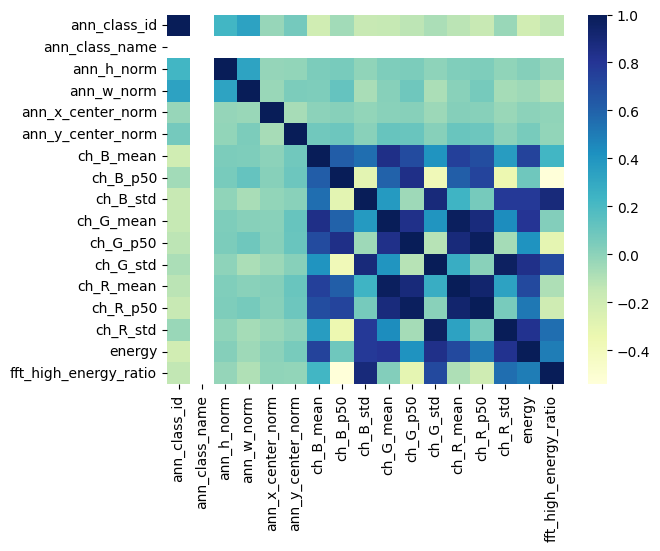

In [12]:
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns, cmap='YlGnBu')

In [13]:
#ANALISE DE COMPONENTES PRINCIPAIS
# DECOMPONDOA A MATRIZ DE VARIANCIAS E COVARIANCIAS EM COMPONENETES PRINCIPAIS

X = np.asarray(dfauto.iloc[:,0:16])
S = np.cov(X)

AttributeError: 'float' object has no attribute 'shape'

In [14]:
X

array([[-0.794484732004858, nan, nan, ..., 1.2307359939738678,
        -1.5540738906863794, -0.38470899677540543],
       [-0.794484732004858, nan, nan, ..., 0.9476851671738807,
        -0.4627164348754423, 0.41287540538002165],
       [-0.794484732004858, nan, nan, ..., 1.0420354427738765,
        -1.4441500851731277, -0.39518823353332544],
       ...,
       [-0.794484732004858, nan, nan, ..., -4.713331368825858,
        -2.631676705599848, -4.5545580976968605],
       [-0.794484732004858, nan, nan, ..., -5.845534676025806,
        -4.681836896744614, -5.307805442249245],
       [-0.794484732004858, nan, nan, ..., -5.845534676025806,
        -5.711308428071971, -5.506669372928805]], dtype=object)

In [15]:
#VARIANCAS DE CADA VARIAVEL
np.diagonal(X)

array([-0.794484732004858, nan, nan, nan, nan, nan, 0.3464155798228908,
       1.34051928932085, -1.1030274393320434, 0.8569562357334558,
       1.1586228244101278, 0.6149300016499734, 0.7195110075185216,
       1.1363857183738721, -1.729697680555978, 0.5584273915074757],
      dtype=object)

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)

In [17]:
pca.fit(X)
pca.components_
# pca.components_.shape
# pca.components_[2,:]

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [18]:
#VARIANCIA DOS COMPONENTES PRINCIPAIS
pca.explained_variance_ratio_
np.round(pca.explained_variance_ratio_, 2)

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [33]:
pca.explained_variance_ratio_.cumsum()

# Se trazermos os primeiros 6 PCAs chegamos em 0.83
# Com 6 variaveis substituo 13

array([0.40664836, 0.52027858, 0.61619573, 0.69362647, 0.76677426,
       0.83659849, 0.89309967, 0.92989921, 0.96296454, 0.98714283])

Text(0, 0.5, 'Eigenvalue')

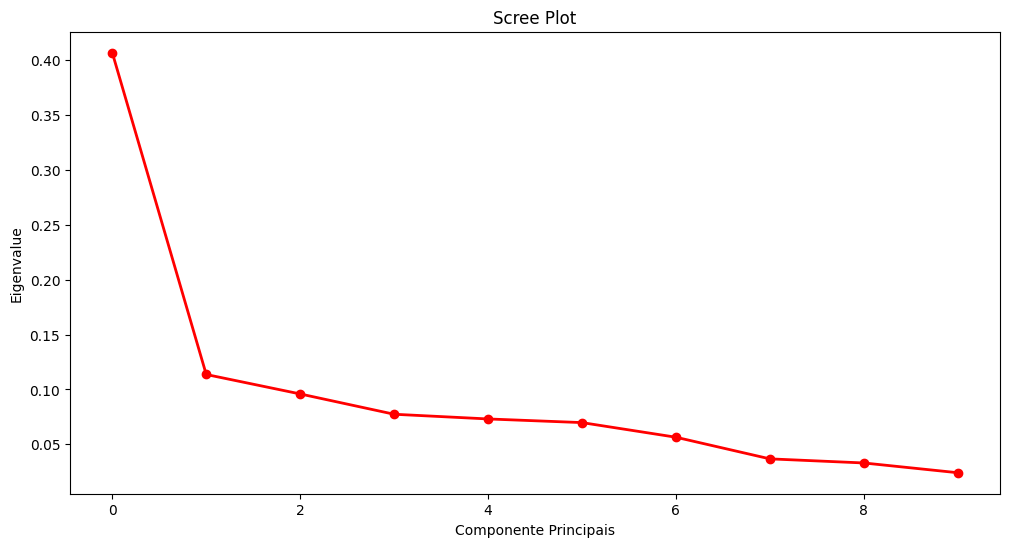

In [34]:
fig = plt.figure(figsize=(12, 6))

plt.plot(pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Componente Principais')
plt.ylabel('Eigenvalue')

In [35]:
pca.transform(X)

array([[ 0.5747458 , -1.03000605, -0.92481018, ..., -0.38605016,
        -0.58900096,  0.31691339],
       [ 3.4459647 , -1.06965421, -0.48742613, ..., -0.35361894,
        -0.27777331,  0.01136052],
       [ 0.71153417, -1.25550577, -1.12036973, ...,  0.26210954,
        -0.48846996,  0.34926499],
       ...,
       [ 0.67332242, -1.72728666, -1.09686962, ...,  0.3622901 ,
         0.01191355,  0.4376241 ],
       [-3.80070725, -0.8600752 , -1.29030622, ...,  0.73167726,
         0.06608066, -0.50641621],
       [-1.20404792, -0.55370887, -1.26014924, ...,  1.02445765,
         0.38453617,  1.23961534]])

In [36]:
pca_6 = PCA(n_components=6)
pca_6.fit(X)
pca_6.components_

array([[-0.02236732, -0.07352569,  0.27246647,  0.37294506,  0.398917  ,
         0.39583821,  0.3862694 ,  0.13605709, -0.02382736,  0.06717635,
         0.21320289,  0.34162772,  0.34743988,  0.09627872],
       [-0.32894973, -0.47418108, -0.24310087, -0.19062131, -0.12179285,
        -0.0556761 , -0.03185008,  0.35014898, -0.08282766,  0.61900306,
         0.13179789,  0.10256212,  0.08681195, -0.06713118],
       [ 0.64582557, -0.30766996, -0.03168689, -0.06950164, -0.08582578,
        -0.09173162, -0.08881458,  0.57395568,  0.08650106, -0.27170043,
        -0.06061322,  0.08905354,  0.11991496,  0.14843327],
       [ 0.01624602,  0.25178542, -0.44103327, -0.20787957, -0.05878722,
         0.01439302,  0.06862335, -0.13499267,  0.65664085,  0.01812251,
         0.27583064,  0.24791942,  0.21298912,  0.24000843],
       [-0.28704114, -0.01142729,  0.25134321,  0.10073997, -0.03187118,
        -0.11469759, -0.13707032,  0.07465682,  0.14503366,  0.09676919,
        -0.45241356,  0.00

In [37]:
np.round(pca_6.components_[0],3)

array([-0.022, -0.074,  0.272,  0.373,  0.399,  0.396,  0.386,  0.136,
       -0.024,  0.067,  0.213,  0.342,  0.347,  0.096])

In [38]:
PCA1 = pca_6.transform(X)[:,0]
PCA2 = pca_6.transform(X)[:,1]
PCA3 = pca_6.transform(X)[:,2]
PCA4 = pca_6.transform(X)[:,3]
PCALL = pca_6.transform(X)



In [39]:
df['PCA1'] = PCA1
df['PCA2'] = PCA2
df['PCA3'] = PCA3
df['PCA4'] = PCA4
df.head()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID,PCA1,PCA2,PCA3,PCA4
class,,,,,,,,,,,,,,,,,,
GALAXY,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,0.634794,5812,56354,171,0.574746,-1.030006,-0.924810,-1.072722
GALAXY,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,0.779136,10445,58158,427,3.445965,-1.069654,-0.487426,1.132695
GALAXY,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,0.644195,4576,55592,299,0.711534,-1.255506,-1.120370,-1.426926
GALAXY,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,0.932346,9149,58039,775,2.554355,0.057736,1.135439,0.295730
GALAXY,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,0.116123,6121,56187,842,-2.832267,0.771239,2.817014,0.838103


In [40]:
df.sort_values(by='PCA1', ascending=False).head(50)

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID,PCA1,PCA2,PCA3,PCA4
class,,,,,,,,,,,,,,,,,,
QSO,8.637128,-1.127558,24.58678,24.46593,22.82553,21.62336,22.53122,4263,1,173,1.396341,9404,58045,894,4.564413,0.529346,-1.122467,-0.991903
GALAXY,40.497678,3.560161,23.20226,24.53431,23.82936,22.09652,22.75254,7718,2,259,0.530157,9416,58098,314,4.553135,1.299974,-0.542272,-1.176797
GALAXY,338.518632,-0.370662,24.36890,24.89395,23.60455,22.12098,22.23246,4192,3,212,0.734745,9217,57934,519,4.377726,-0.534290,0.598754,-0.528610
QSO,329.999623,3.726588,22.99822,22.15485,22.08356,22.02047,22.12553,7765,3,122,1.865205,11329,58426,1000,4.301447,0.201708,2.101963,1.014322
GALAXY,24.952626,2.378935,23.65257,23.76629,22.90933,22.02259,21.35769,7717,4,496,0.724460,9398,58124,764,4.256454,2.520094,-0.642313,0.319708
GALAXY,40.291114,3.586411,24.76180,23.50528,22.25379,21.97982,21.52896,7718,2,257,0.765215,9417,58055,624,4.077364,1.307323,-0.232915,-1.027704
GALAXY,134.281988,24.104792,23.40868,24.58809,22.48084,21.74477,21.81027,4576,4,148,1.605999,9598,58085,492,3.987905,-0.540263,-0.678714,0.902837
GALAXY,40.125506,3.504013,23.04723,22.91427,22.99111,22.17126,21.21337,7718,2,256,0.931355,9417,58055,584,3.914103,1.549012,-0.248205,-0.618247
QSO,341.502909,-0.308397,25.00198,23.11789,22.43975,21.29501,21.33819,4192,3,232,1.830383,9218,57724,842,3.871385,-0.110088,0.843090,0.206959


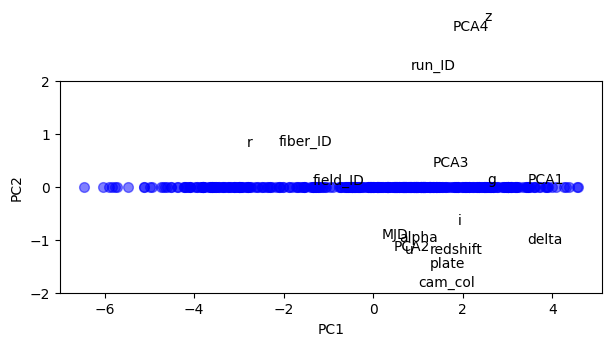

In [41]:
marker = dict(linestyle='none', marker='o', markersize=7, color='blue', alpha=0.5)
fix, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, np.zeros_like(PCA2), label="Scores", **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim(-2, 2)

text = [ax.text(x, y, t) for x, y, t in zip(PCA1, PCA2, df.columns)]

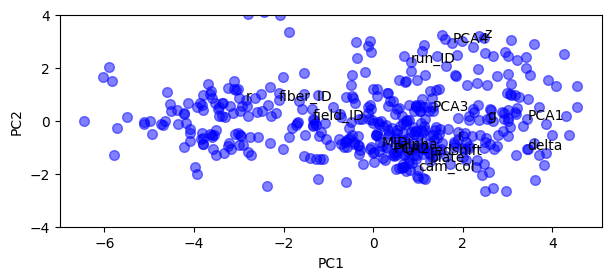

In [42]:
fix, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, PCA2, label="Scores", **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim(-4, 4)

text = [ax.text(x, y, t) for x, y, t in 
        zip(PCA1, PCA2, df.columns)]